# Polar Representation of Brownian Dynamics

We can now consider the dynamics of Brown Particles in two dimensions in the absence of external forces. We can represent the particles' velocities in polar coordinates. Where they are given by the scalar speed $s(t)$ ($s\ge 0$) and polar angle (angle measured between the velocity and x-axis) $\phi(t)$.

$$\mathbf{v_x(t)} = s(t) \cos{\phi(t)}$$
$$\mathbf{v_y(t)} = s(t) \sin{\phi(t)}$$

The corresponding stochastic equations for $s(t)$ and $\phi(t)$ are given as:
$$\frac{ds}{dt} = -\gamma s(t) dt + \sqrt{2D}[\cos{\phi} \circ \xi_x (t) + \sin{\phi} \circ \xi_y (t)]$$
$$\frac{d\phi}{dt} = \frac{\sqrt{2D}}{s}[-\sin{\phi} \circ \xi_x (t) + \cos{\phi} \circ \xi_y (t)]$$

Here, the noise is multiplicative and is interpreted in the Stratonovich sense. When performing the Leapfrog discretisation, the equations become implicit; hence, to avoid this and for simplicity, we can sample the noise directly from $\mathcal{N}(0,1)$. This because
$$\xi_s(t) = \cos{\phi} \circ \xi_x (t) + \sin{\phi} \circ \xi_y (t) $$
$$\xi_\phi(t) = -\sin{\phi} \circ \xi_x (t) + \cos{\phi} \circ \xi_y (t) $$
are just rotations of two independent Gaussian noises. A rotation of independent standard Gaussians gives independent standard Gaussians again. Therefore, for simulation purposes, you can draw directly $\xi_s(t)$, $\xi_\phi(t)$ from $\mathcal{N}(0,1)$. 

The $\braket{\xi_s(t)}$ doesn't vanish [[1]](https://arxiv.org/abs/1202.2442), meaning that the polar transformation of Cartesian Langevin noise, the speed noise, has a nonzero mean. To account for this, we add a noise-induced drift term to the s-update. Finally, the leapfrog steps are

Half-time Velocity update:
$$s_{i+1/2} = s_i - \frac{\gamma}{2} s_i \Delta t + \frac{D}{s_i}\Delta t + \sqrt{D \Delta t} \xi^{(1)}_s$$
$$\phi_{i+1/2} = \phi_i + \frac{\sqrt{D \Delta t}}{s_{i+1/4}} \xi^{(1)}_{\phi} $$

Where, $s_{i+1/4} = \frac{s_i + s_{i+1/2}}{2}$

Full-time position update:

$$
\mathbf r_{i+1}
=
\mathbf r_i
+
s_{i+\frac12}
\begin{pmatrix}
\cos\phi_{i+\frac12} \\
\sin\phi_{i+\frac12}
\end{pmatrix}
\Delta t
$$

Full-time Velocity update:
$$s_{i+1} = s_{i+1/2}  - \frac{\gamma}{2} s_{i+1/2}  \Delta t + \frac{D}{s_{i+1/2}}\Delta t + \sqrt{D \Delta t} \xi^{(2)}_s$$
$$\phi_{i+1} = \phi_{i+1/2} + \frac{\sqrt{D \Delta t}}{s_{i+3/4}} + \xi^{(2)}_{\phi} $$

Where, $s_{i+3/4} = \frac{s_{i+1} + s_{i+1/2}}{2}$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from polar_zero_potential import integrate_abp_polar_leapfrog

Below is a simple implementation of the above integration steps.

In [2]:
time, r, s, phi = integrate_abp_polar_leapfrog(
    r0=[0.0, 0.0],
    s0=1.0,
    phi0=0.0,
    n_steps=10000,
    dt=1e-3,
    gamma=1.0,
    D=0.1,
    seed=42,
)

x = r[:, 0]
y = r[:, 1]

Text(0.5, 1.0, '2D Trajectory of a Brownian Particle')

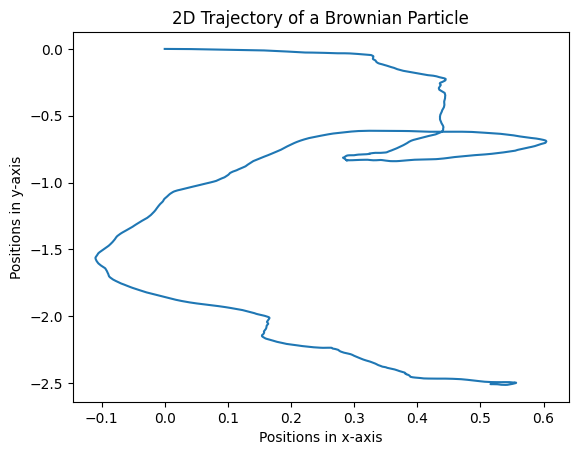

In [3]:
plt.plot(x,y)
plt.xlabel("Positions in x-axis")
plt.ylabel("Positions in y-axis")
plt.title("2D Trajectory of a Brownian Particle")